In [1]:
from google.colab import files

uploaded = files.upload()

Saving online+retail+ii.zip to online+retail+ii.zip


In [2]:
import os

print("Files in Colab:")
print(os.listdir())

Files in Colab:
['.config', 'online+retail+ii.zip', 'sample_data']


In [3]:
import pandas as pd

In [6]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles in current folder:")
print(os.listdir())

Current folder:
/content

Files in current folder:
['.config', 'online+retail+ii.zip', 'sample_data']


In [7]:
import zipfile
import os

zip_file = "online+retail+ii.zip"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("retail_data")

print("ZIP file extracted successfully!")
print("Files inside the extracted folder:")
print(os.listdir("retail_data"))

ZIP file extracted successfully!
Files inside the extracted folder:
['online_retail_II.xlsx']


In [8]:
import os

files_in_folder = os.listdir("retail_data")

print("Extracted files:")
for file in files_in_folder:
    print(file)

Extracted files:
online_retail_II.xlsx


In [9]:
import os
import pandas as pd

# Find the Excel file inside the extracted folder
excel_files = []

for root, folders, files in os.walk("retail_data"):
    for file in files:
        if file.lower().endswith((".xlsx", ".xls")):
            excel_files.append(os.path.join(root, file))

print("Excel files found:")
for file in excel_files:
    print(file)

Excel files found:
retail_data/online_retail_II.xlsx


In [10]:
excel_file = excel_files[0]

df = pd.read_excel(excel_file)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 525461
Columns: 8


In [11]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


In [12]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


In [13]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 6865


In [14]:
print("Data types:")
print(df.dtypes)

Data types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


In [15]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("InvoiceDate converted successfully!")
print(df["InvoiceDate"].dtype)

InvoiceDate converted successfully!
datetime64[ns]


In [16]:
negative_quantity = (df["Quantity"] < 0).sum()

print("Transactions with negative quantity:", negative_quantity)

Transactions with negative quantity: 12326


In [17]:
invalid_price = (df["Price"] <= 0).sum()

print("Transactions with zero or negative price:", invalid_price)

Transactions with zero or negative price: 3690


In [18]:
clean_df = df.copy()

print("Clean dataset copy created!")
print("Original rows:", len(df))
print("Clean dataset rows:", len(clean_df))

Clean dataset copy created!
Original rows: 525461
Clean dataset rows: 525461


In [19]:
clean_df = clean_df.drop_duplicates()

print("Duplicates removed.")
print("Rows after removing duplicates:", len(clean_df))

Duplicates removed.
Rows after removing duplicates: 518596


In [20]:
clean_df = clean_df[clean_df["Quantity"] > 0]

print("Invalid/negative quantities removed.")
print("Rows remaining:", len(clean_df))

Invalid/negative quantities removed.
Rows remaining: 506294


In [21]:
clean_df = clean_df[clean_df["Quantity"] > 0]

print("Invalid/negative quantities removed.")
print("Rows remaining:", len(clean_df))

Invalid/negative quantities removed.
Rows remaining: 506294


In [22]:
clean_df = clean_df.dropna(subset=["Description"])

print("Missing descriptions removed.")
print("Rows remaining:", len(clean_df))

Missing descriptions removed.
Rows remaining: 505193


In [23]:
missing_customer_id = clean_df["Customer ID"].isnull().sum()

print("Missing Customer IDs:", missing_customer_id)

Missing Customer IDs: 104246


In [24]:
clean_df = clean_df.dropna(subset=["Customer ID"])

print("Missing Customer IDs removed.")
print("Rows remaining:", len(clean_df))

Missing Customer IDs removed.
Rows remaining: 400947


In [25]:
clean_df["Customer ID"] = clean_df["Customer ID"].astype(int)

print("Customer ID converted to integer.")
print(clean_df["Customer ID"].dtype)

Customer ID converted to integer.
int64


In [26]:
clean_df["Total_Sales"] = clean_df["Quantity"] * clean_df["Price"]

print("Total_Sales feature created!")
clean_df[["Quantity", "Price", "Total_Sales"]].head()

Total_Sales feature created!


,Quantity,Price,Total_Sales
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [27]:
clean_df["Year"] = clean_df["InvoiceDate"].dt.year
clean_df["Month"] = clean_df["InvoiceDate"].dt.month
clean_df["Day"] = clean_df["InvoiceDate"].dt.day
clean_df["Hour"] = clean_df["InvoiceDate"].dt.hour

print("Date features created successfully!")

Date features created successfully!


In [28]:
clean_df["Month_Name"] = clean_df["InvoiceDate"].dt.month_name()

print("Month_Name created!")
clean_df[["InvoiceDate", "Year", "Month", "Month_Name"]].head()

Month_Name created!


,InvoiceDate,Year,Month,Month_Name
0,2009-12-01 07:45:00,2009,12,December
1,2009-12-01 07:45:00,2009,12,December
2,2009-12-01 07:45:00,2009,12,December
3,2009-12-01 07:45:00,2009,12,December
4,2009-12-01 07:45:00,2009,12,December


In [29]:
clean_df["Day_of_Week"] = clean_df["InvoiceDate"].dt.day_name()

print("Day_of_Week created!")
clean_df[["InvoiceDate", "Day_of_Week"]].head()

Day_of_Week created!


,InvoiceDate,Day_of_Week
0,2009-12-01 07:45:00,Tuesday
1,2009-12-01 07:45:00,Tuesday
2,2009-12-01 07:45:00,Tuesday
3,2009-12-01 07:45:00,Tuesday
4,2009-12-01 07:45:00,Tuesday


In [30]:
clean_df["Transaction"] = 1

print("Transaction feature created!")

Transaction feature created!


In [31]:
print("Cleaned Dataset Shape:")
print(clean_df.shape)

print("\nCleaned Dataset Columns:")
print(clean_df.columns.tolist())

Cleaned Dataset Shape:
(400947, 16)

Cleaned Dataset Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Total_Sales', 'Year', 'Month', 'Day', 'Hour', 'Month_Name', 'Day_of_Week', 'Transaction']


In [32]:
print("Missing values after cleaning:")
print(clean_df.isnull().sum())

Missing values after cleaning:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Total_Sales    0
Year           0
Month          0
Day            0
Hour           0
Month_Name     0
Day_of_Week    0
Transaction    0
dtype: int64


In [33]:
print("Duplicate rows after cleaning:", clean_df.duplicated().sum())

Duplicate rows after cleaning: 0


In [34]:
clean_df.describe()

,Quantity,InvoiceDate,Price,Customer ID,Total_Sales,Year,Month,Day,Hour,Transaction
count,400947.000000,400947,400947.000000,400947.000000,400947.000000,400947.000000,400947.000000,400947.000000,400947.000000,400947.0
mean,13.768523,2010-07-01 04:56:11.466452992,3.305571,15361.454639,21.943633,2009.924481,7.398197,15.365108,12.865202,1.0
min,1.000000,2009-12-01 07:45:00,0.000000,12346.000000,0.000000,2009.000000,1.000000,1.000000,7.000000,1.0
25%,2.000000,2010-03-26 13:13:00,1.250000,13985.000000,5.000000,2010.000000,4.000000,8.000000,11.000000,1.0
50%,5.000000,2010-07-09 10:26:00,1.950000,15311.000000,12.500000,2010.000000,8.000000,15.000000,13.000000,1.0
75%,12.000000,2010-10-14 13:57:00,3.750000,16805.000000,19.500000,2010.000000,11.000000,23.000000,14.000000,1.0
max,19152.000000,2010-12-09 20:01:00,10953.500000,18287.000000,15818.400000,2010.000000,12.000000,31.000000,20.000000,1.0
std,97.639816,NaN,35.046376,1680.669487,77.755308,0.264227,3.472228,8.735054,2.306908,0.0


In [35]:
clean_df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total_Sales,Year,Month,Day,Hour,Month_Name,Day_of_Week,Transaction
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,1,7,December,Tuesday,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,1,7,December,Tuesday,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,1,7,December,Tuesday,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,12,1,7,December,Tuesday,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,12,1,7,December,Tuesday,1
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085,United Kingdom,39.6,2009,12,1,7,December,Tuesday,1
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,12,1,7,December,Tuesday,1
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085,United Kingdom,59.5,2009,12,1,7,December,Tuesday,1
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085,United Kingdom,30.6,2009,12,1,7,December,Tuesday,1
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085,United Kingdom,45.0,2009,12,1,7,December,Tuesday,1


In [36]:
clean_df.to_csv(
    "online_retail_II_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [37]:
import os

print("File exists:", os.path.exists("online_retail_II_cleaned.csv"))

File exists: True


In [38]:
total_revenue = clean_df["Total_Sales"].sum()
total_quantity = clean_df["Quantity"].sum()
total_customers = clean_df["Customer ID"].nunique()
total_products = clean_df["StockCode"].nunique()
total_orders = clean_df["Invoice"].nunique()

print("===== BUSINESS KPIs =====")
print("Total Revenue:", round(total_revenue, 2))
print("Total Quantity Sold:", total_quantity)
print("Total Customers:", total_customers)
print("Total Products:", total_products)
print("Total Orders:", total_orders)

===== BUSINESS KPIs =====
Total Revenue: 8798233.74
Total Quantity Sold: 5520448
Total Customers: 4314
Total Products: 4017
Total Orders: 19215


In [39]:
average_order_value = total_revenue / total_orders

print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 457.88


In [40]:
customer_sales = (
    clean_df.groupby("Customer ID")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

customer_sales.head(10)

,Total_Sales
Customer ID,
18102,349164.35
14646,248396.50
14156,196549.74
14911,152121.22
13694,131443.19
17511,84541.17
15061,83284.38
16684,80489.21
16754,65500.07


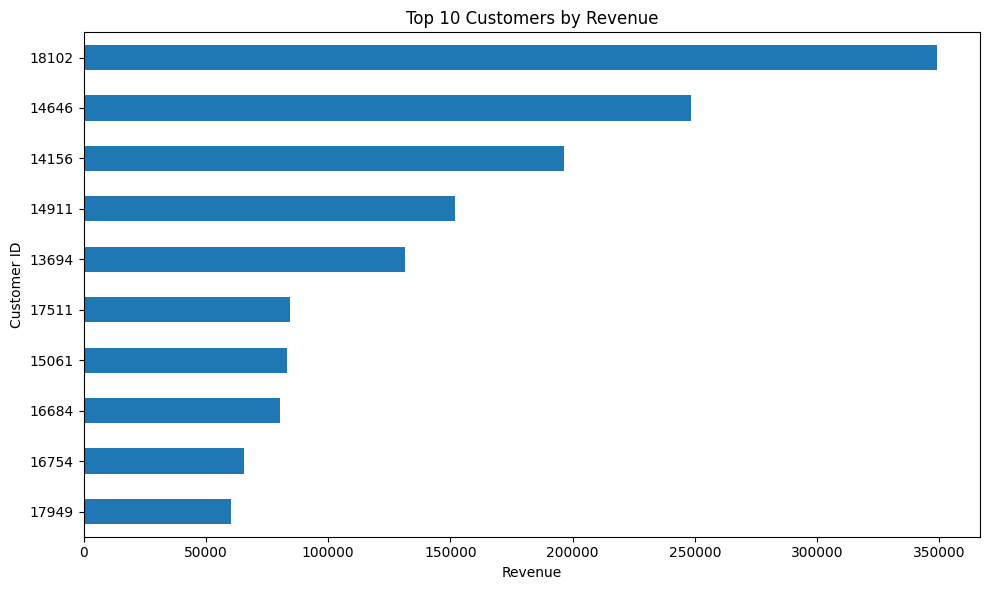

In [41]:
import matplotlib.pyplot as plt

top_customers = customer_sales.head(10)

plt.figure(figsize=(10, 6))
top_customers.sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.show()

In [42]:
product_sales = (
    clean_df.groupby("Description")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

product_sales.head(10)

,Total_Sales
Description,
WHITE HANGING HEART T-LIGHT HOLDER,151339.16
REGENCY CAKESTAND 3 TIER,143727.60
Manual,98531.99
ASSORTED COLOUR BIRD ORNAMENT,70291.03
JUMBO BAG RED RETROSPOT,51644.25
POSTAGE,48741.08
ROTATING SILVER ANGELS T-LIGHT HLDR,40156.05
PAPER CHAIN KIT 50'S CHRISTMAS,36871.55
PARTY BUNTING,35017.30


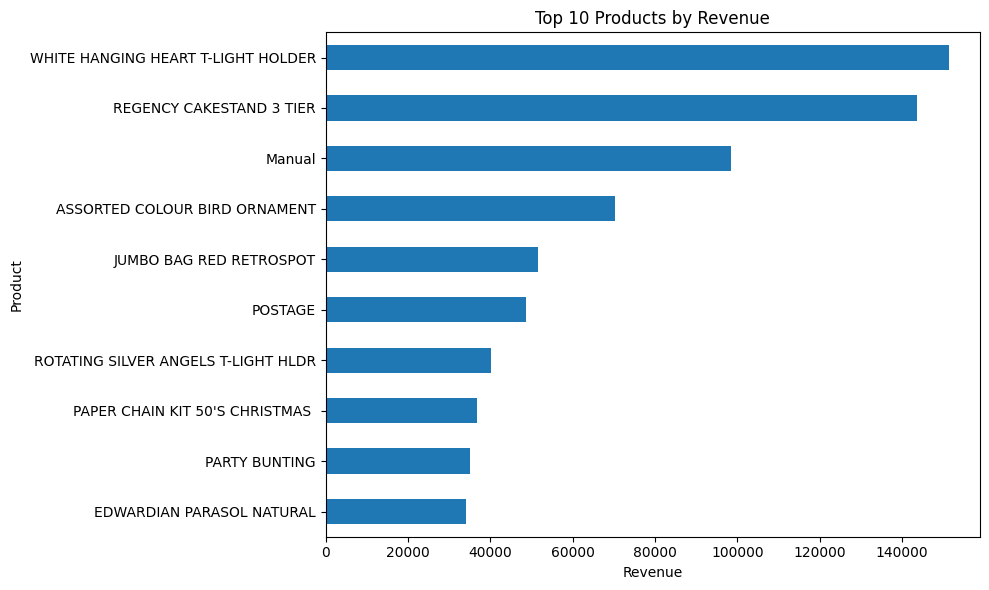

In [43]:
top_products = product_sales.head(10)

plt.figure(figsize=(10, 6))
top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [44]:
country_sales = (
    clean_df.groupby("Country")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

country_sales.head(10)

,Total_Sales
Country,
United Kingdom,7381644.433
EIRE,356041.860
Netherlands,268784.350
Germany,202025.391
France,146107.070
Sweden,53147.990
Denmark,50906.850
Spain,47568.650
Switzerland,43921.390


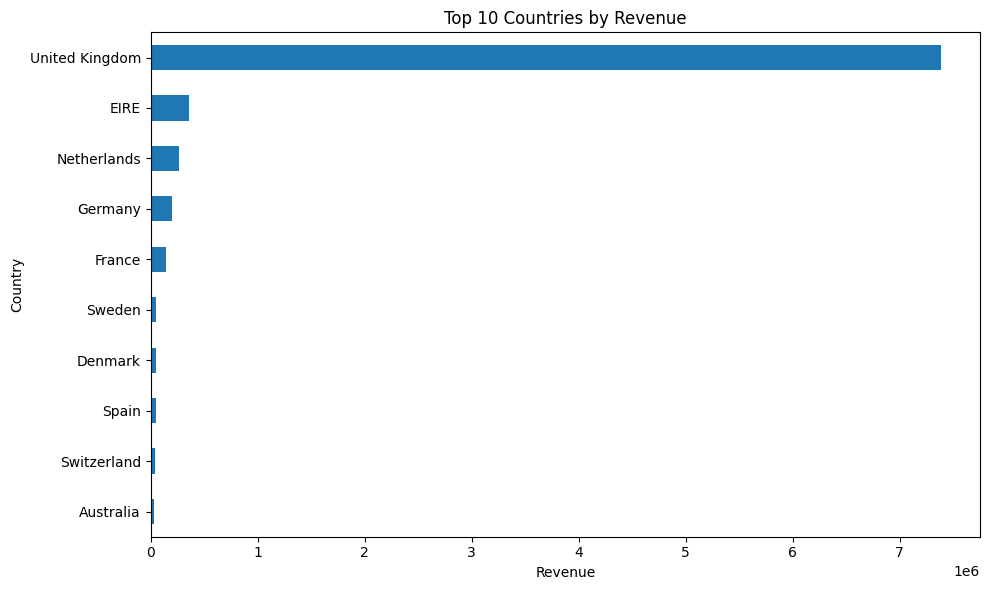

In [45]:
top_countries = country_sales.head(10)

plt.figure(figsize=(10, 6))
top_countries.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [47]:
monthly_sales = (
    clean_df.groupby(
        clean_df["InvoiceDate"].dt.to_period("M")
    )["Total_Sales"]
    .sum()
)

monthly_sales.head()

,Total_Sales
InvoiceDate,
2009-12,683504.010
2010-01,555802.672
2010-02,504558.956
2010-03,696978.471
2010-04,591982.002


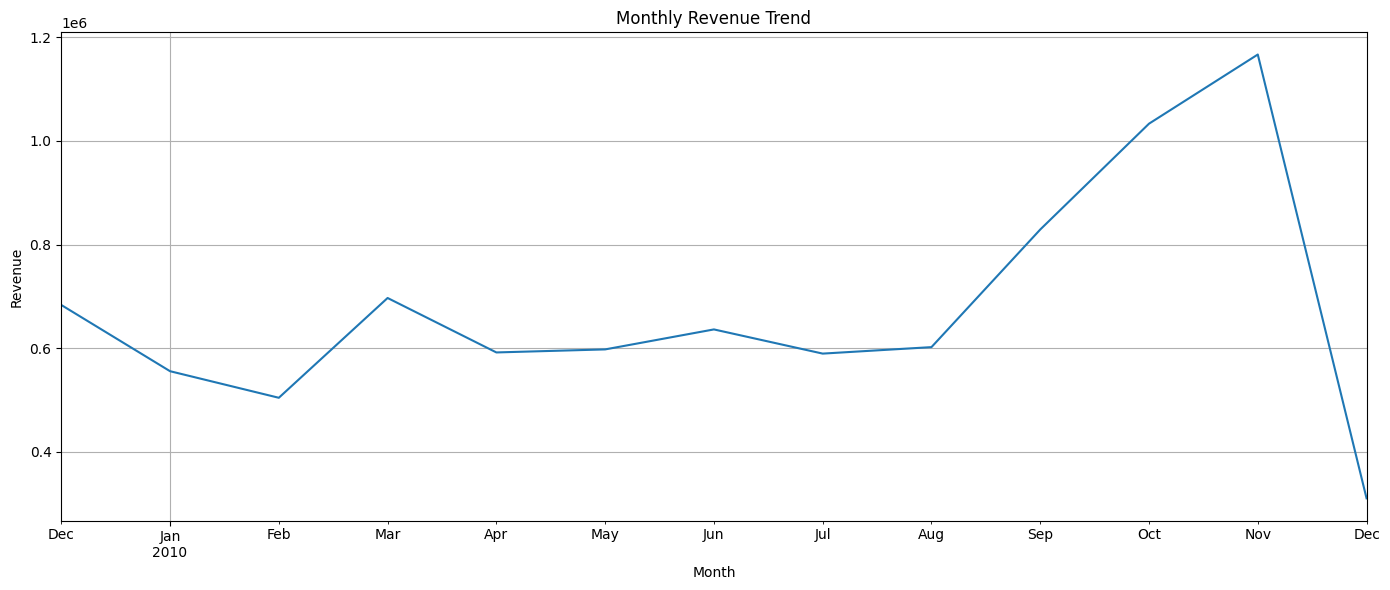

In [48]:
plt.figure(figsize=(14, 6))

monthly_sales.plot()

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.tight_layout()
plt.show()

In [49]:
yearly_sales = (
    clean_df.groupby("Year")["Total_Sales"]
    .sum()
)

print(yearly_sales)

Year
2009     683504.010
2010    8114729.734
Name: Total_Sales, dtype: float64


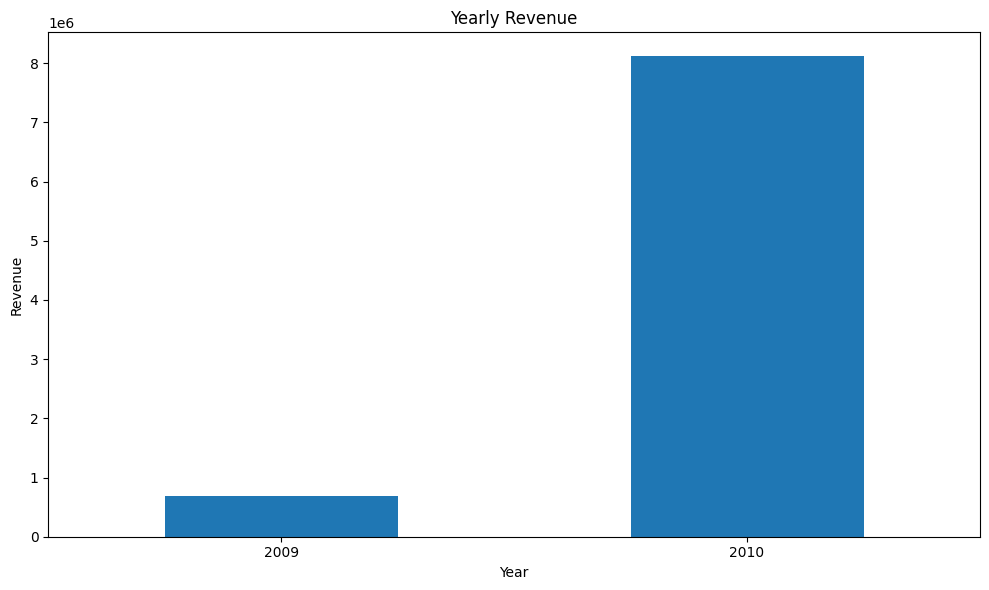

In [50]:
plt.figure(figsize=(10, 6))

yearly_sales.plot(kind="bar")

plt.title("Yearly Revenue")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [51]:
monthly_average = (
    clean_df.groupby("Month")["Total_Sales"]
    .mean()
)

print(monthly_average)

Month
1     25.898265
2     21.897359
3     21.929285
4     22.060893
5     21.174986
6     20.734780
7     22.133920
8     23.135789
9     24.289178
10    21.202915
11    19.801049
12    22.358771
Name: Total_Sales, dtype: float64


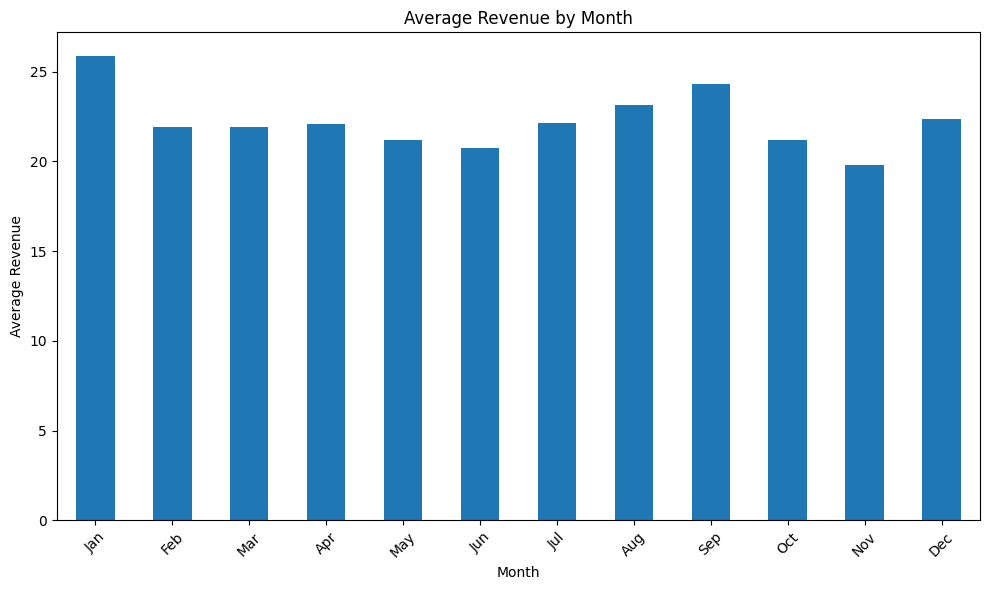

In [52]:
plt.figure(figsize=(10, 6))

monthly_average.plot(kind="bar")

plt.title("Average Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Average Revenue")
plt.xticks(range(12), [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
], rotation=45)

plt.tight_layout()
plt.show()

In [53]:
weekday_sales = (
    clean_df.groupby("Day_of_Week")["Total_Sales"]
    .sum()
)

weekday_sales

,Total_Sales
Day_of_Week,
Friday,1269250.992
Monday,1445606.495
Saturday,9803.050
Sunday,1014540.011
Thursday,1858159.182
Tuesday,1678827.301
Wednesday,1522046.713


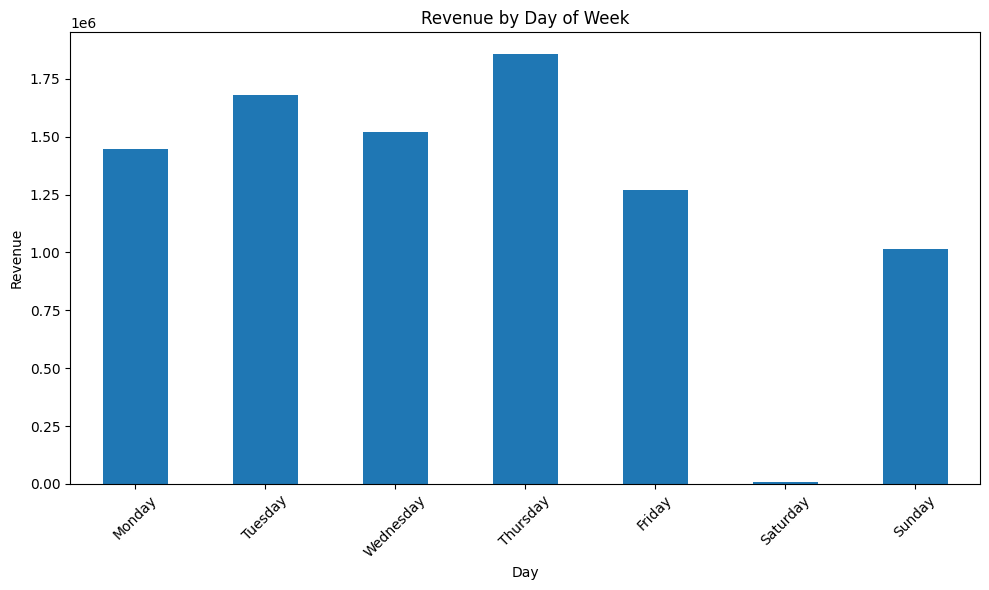

In [54]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_sales = weekday_sales.reindex(weekday_order)

plt.figure(figsize=(10, 6))

weekday_sales.plot(kind="bar")

plt.title("Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [55]:
hourly_sales = (
    clean_df.groupby("Hour")["Total_Sales"]
    .sum()
)

hourly_sales

,Total_Sales
Hour,
7,45153.360
8,246746.730
9,666946.380
10,1097775.752
11,1162412.333
12,1365413.491
13,1221212.854
14,995488.010
15,913114.452


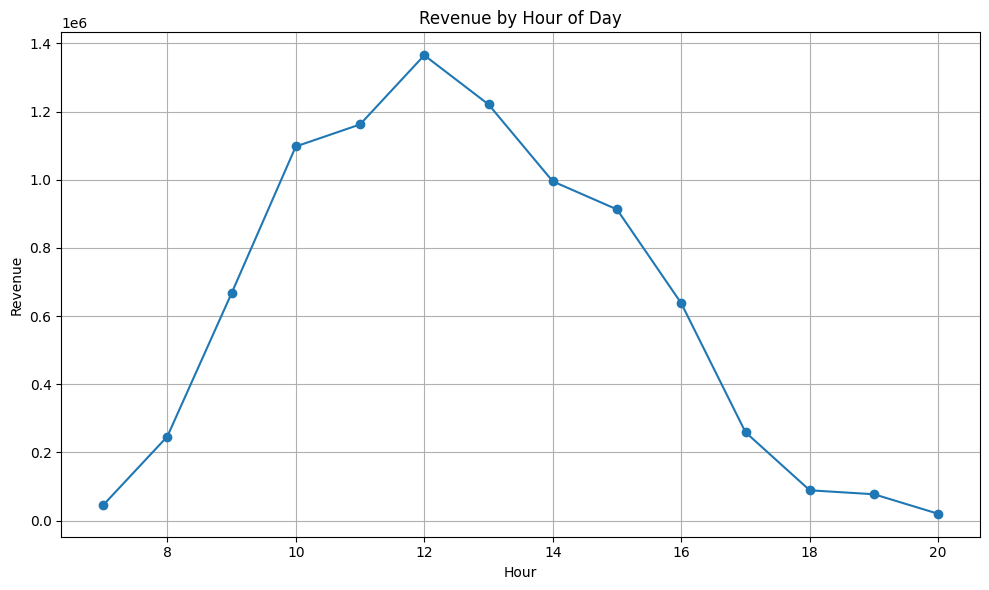

In [56]:
plt.figure(figsize=(10, 6))

hourly_sales.plot(kind="line", marker="o")

plt.title("Revenue by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.grid(True)

plt.tight_layout()
plt.show()

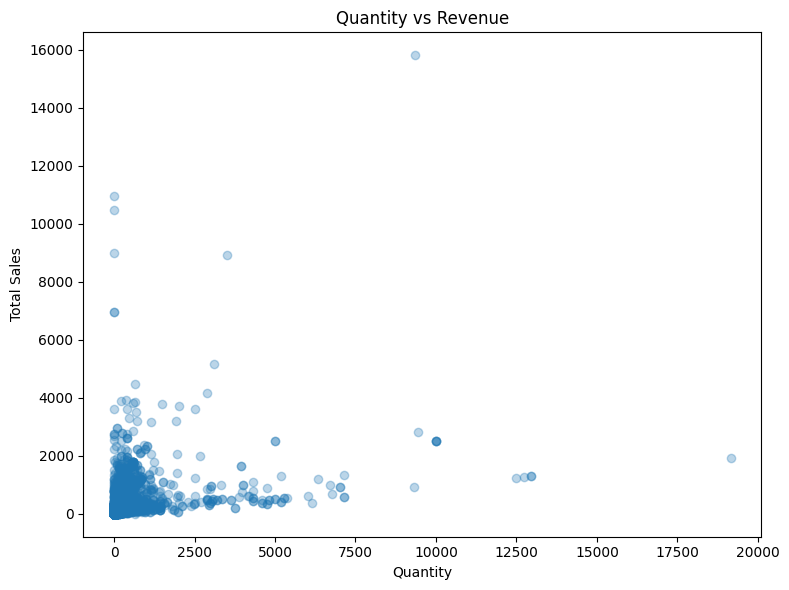

In [57]:
plt.figure(figsize=(8, 6))

plt.scatter(
    clean_df["Quantity"],
    clean_df["Total_Sales"],
    alpha=0.3
)

plt.title("Quantity vs Revenue")
plt.xlabel("Quantity")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

In [58]:
correlation = clean_df[
    ["Quantity", "Price", "Total_Sales", "Year", "Month", "Hour"]
].corr()

correlation

,Quantity,Price,Total_Sales,Year,Month,Hour
Quantity,1.000000,-0.006888,0.414202,0.001758,-0.012703,-0.020427
Price,-0.006888,1.000000,0.452306,0.000804,-0.004604,-0.001342
Total_Sales,0.414202,0.452306,1.000000,-0.002315,-0.007027,-0.043738
Year,0.001758,0.000804,-0.002315,1.000000,-0.378790,-0.028550
Month,-0.012703,-0.004604,-0.007027,-0.378790,1.000000,0.040123
Hour,-0.020427,-0.001342,-0.043738,-0.028550,0.040123,1.000000


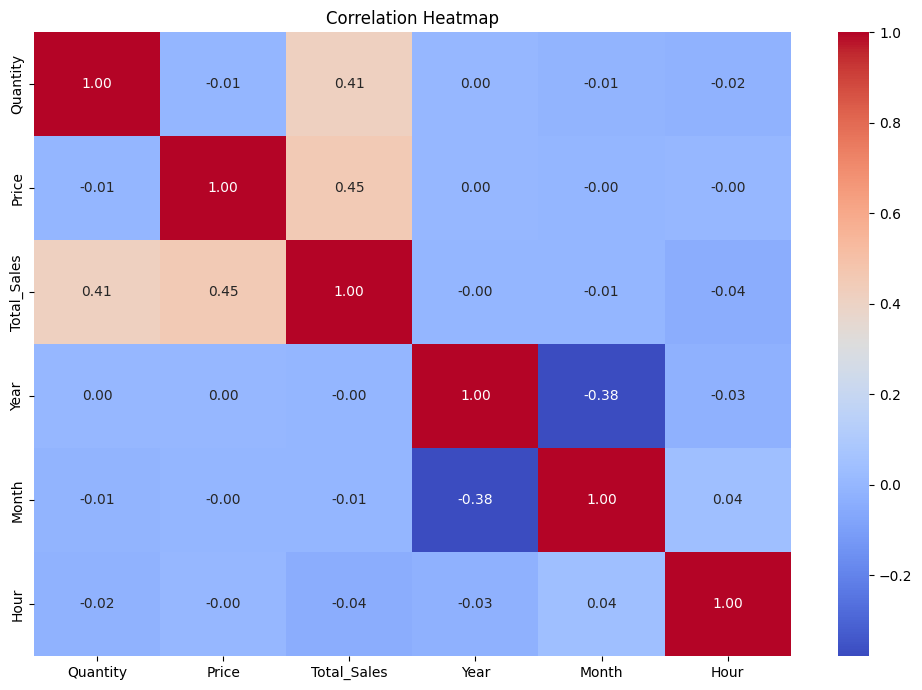

In [59]:
import seaborn as sns

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [60]:
customer_frequency = (
    clean_df.groupby("Customer ID")["Invoice"]
    .nunique()
    .sort_values(ascending=False)
)

customer_frequency.head(10)

,Invoice
Customer ID,
14911,205
17850,155
12748,144
15311,121
13089,109
14606,102
14156,102
13694,94
17841,91


In [61]:
customer_quantity = (
    clean_df.groupby("Customer ID")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

customer_quantity.head(10)

,Quantity
Customer ID,
13902,220600
14646,170342
13694,125893
18102,124216
14156,108105
14277,87830
13687,87167
17940,75825
14911,69709


In [62]:
customer_summary = clean_df.groupby("Customer ID").agg(
    Total_Spending=("Total_Sales", "sum"),
    Total_Orders=("Invoice", "nunique"),
    Total_Quantity=("Quantity", "sum"),
    Average_Order_Value=("Total_Sales", "mean"),
    Product_Count=("StockCode", "nunique"),
    Country=("Country", "first")
).reset_index()

customer_summary.head()

,Customer ID,Total_Spending,Total_Orders,Total_Quantity,Average_Order_Value,Product_Count,Country
0,12346,372.86,11,70,11.298788,26,United Kingdom
1,12347,1323.32,2,828,18.638310,70,Iceland
2,12348,222.16,1,373,11.108000,20,Finland
3,12349,2671.14,3,993,26.187647,90,Italy
4,12351,300.93,1,261,14.330000,21,Unspecified


In [63]:
customer_summary.describe()

,Customer ID,Total_Spending,Total_Orders,Total_Quantity,Average_Order_Value,Product_Count
count,4314.000000,4314.000000,4314.000000,4314.000000,4314.000000,4314.000000
mean,15348.880389,2039.460766,4.454103,1279.658785,36.986943,63.618220
std,1700.930104,8909.797773,8.168658,6457.213973,217.659847,85.753098
min,12346.000000,0.000000,1.000000,1.000000,0.000000,1.000000
25%,13883.250000,307.105000,1.000000,156.000000,11.185231,17.000000
50%,15348.500000,700.405000,2.000000,379.500000,17.357104,38.000000
75%,16833.750000,1713.297500,5.000000,992.000000,24.813257,79.000000
max,18287.000000,349164.350000,205.000000,220600.000000,10953.500000,1741.000000


In [64]:
top_customer_summary = (
    customer_summary
    .sort_values("Total_Spending", ascending=False)
    .head(10)
)

top_customer_summary

,Customer ID,Total_Spending,Total_Orders,Total_Quantity,Average_Order_Value,Product_Count,Country
4185,18102,349164.35,89,124216,556.880941,281,United Kingdom
1638,14646,248396.50,78,170342,140.020575,606,Netherlands
1270,14156,196549.74,102,108105,74.281837,1094,EIRE
1842,14911,152121.22,205,69709,27.320621,1741,EIRE
939,13694,131443.19,94,125893,137.349206,654,United Kingdom
3746,17511,84541.17,31,55107,89.178449,423,United Kingdom
1953,15061,83284.38,86,51791,142.610240,116,United Kingdom
3130,16684,80489.21,27,54555,182.515215,124,United Kingdom
3179,16754,65500.07,29,63551,467.857643,38,United Kingdom
4067,17949,60117.60,74,30112,691.006897,34,United Kingdom


In [65]:
customer_summary.to_csv(
    "customer_behavior_summary.csv",
    index=False
)

print("Customer behavior summary saved successfully!")

Customer behavior summary saved successfully!


In [66]:
best_month = monthly_sales.idxmax()
best_month_sales = monthly_sales.max()

worst_month = monthly_sales.idxmin()
worst_month_sales = monthly_sales.min()

print("Best Month:", best_month)
print("Best Month Revenue:", round(best_month_sales, 2))

print("Lowest Month:", worst_month)
print("Lowest Month Revenue:", round(worst_month_sales, 2))

Best Month: 2010-11
Best Month Revenue: 1166460.02
Lowest Month: 2010-12
Lowest Month Revenue: 310656.37


In [67]:
best_year = yearly_sales.idxmax()
best_year_sales = yearly_sales.max()

worst_year = yearly_sales.idxmin()
worst_year_sales = yearly_sales.min()

print("Best Year:", best_year)
print("Best Year Revenue:", round(best_year_sales, 2))

print("Lowest Year:", worst_year)
print("Lowest Year Revenue:", round(worst_year_sales, 2))

Best Year: 2010
Best Year Revenue: 8114729.73
Lowest Year: 2009
Lowest Year Revenue: 683504.01


In [68]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Quantity",
        "Total Customers",
        "Total Products",
        "Total Orders",
        "Average Order Value",
        "Best Year",
        "Best Year Revenue",
        "Best Month",
        "Best Month Revenue"
    ],
    "Value": [
        total_revenue,
        total_quantity,
        total_customers,
        total_products,
        total_orders,
        average_order_value,
        best_year,
        best_year_sales,
        str(best_month),
        best_month_sales
    ]
})

kpi_summary

,Metric,Value
0,Total Revenue,8798233.744
1,Total Quantity,5520448
2,Total Customers,4314
3,Total Products,4017
4,Total Orders,19215
5,Average Order Value,457.883619
6,Best Year,2010
7,Best Year Revenue,8114729.734
8,Best Month,2010-11
9,Best Month Revenue,1166460.022


In [69]:
kpi_summary.to_csv(
    "business_kpi_summary.csv",
    index=False
)

print("KPI summary saved successfully!")

KPI summary saved successfully!


In [70]:
analysis_date = clean_df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Analysis Date:", analysis_date)

Analysis Date: 2010-12-10 20:01:00


In [71]:
rfm = clean_df.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (analysis_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("Total_Sales", "sum")
).reset_index()

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346,165,11,372.86
1,12347,3,2,1323.32
2,12348,74,1,222.16
3,12349,43,3,2671.14
4,12351,11,1,300.93


In [72]:
rfm.describe()

,Customer ID,Recency,Frequency,Monetary
count,4314.000000,4314.000000,4314.000000,4314.000000
mean,15348.880389,91.269124,4.454103,2039.460766
std,1700.930104,96.943482,8.168658,8909.797773
min,12346.000000,1.000000,1.000000,0.000000
25%,13883.250000,18.000000,1.000000,307.105000
50%,15348.500000,53.000000,2.000000,700.405000
75%,16833.750000,136.000000,5.000000,1713.297500
max,18287.000000,374.000000,205.000000,349164.350000


In [73]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

print("RFM scores created successfully!")

RFM scores created successfully!


In [74]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,165,11,372.86,2,5,2,252
1,12347,3,2,1323.32,5,2,4,524
2,12348,74,1,222.16,2,1,1,211
3,12349,43,3,2671.14,3,3,5,335
4,12351,11,1,300.93,5,1,2,512


In [75]:
def segment_customer(row):
    if row["R_Score"] >= 4 and row["F_Score"] >= 4 and row["M_Score"] >= 4:
        return "Champions"

    elif row["R_Score"] >= 4 and row["F_Score"] >= 3:
        return "Loyal Customers"

    elif row["R_Score"] >= 4 and row["F_Score"] <= 2:
        return "Potential Loyalists"

    elif row["R_Score"] <= 2 and row["F_Score"] >= 3:
        return "At Risk"

    else:
        return "Lost Customers"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

print("Customer segments created!")

Customer segments created!


In [76]:
def segment_customer(row):
    if row["R_Score"] >= 4 and row["F_Score"] >= 4 and row["M_Score"] >= 4:
        return "Champions"

    elif row["R_Score"] >= 4 and row["F_Score"] >= 3:
        return "Loyal Customers"

    elif row["R_Score"] >= 4 and row["F_Score"] <= 2:
        return "Potential Loyalists"

    elif row["R_Score"] <= 2 and row["F_Score"] >= 3:
        return "At Risk"

    else:
        return "Lost Customers"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

print("Customer segments created!")

Customer segments created!


In [77]:
rfm.head(20)

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346,165,11,372.86,2,5,2,252,At Risk
1,12347,3,2,1323.32,5,2,4,524,Potential Loyalists
2,12348,74,1,222.16,2,1,1,211,Lost Customers
3,12349,43,3,2671.14,3,3,5,335,Lost Customers
4,12351,11,1,300.93,5,1,2,512,Potential Loyalists
5,12352,11,2,343.80,5,2,2,522,Potential Loyalists
6,12353,44,1,317.76,3,1,2,312,Lost Customers
7,12355,203,1,488.21,1,1,2,112,Lost Customers
8,12356,16,3,3560.30,4,3,5,435,Loyal Customers
9,12357,24,2,12079.99,4,2,5,425,Potential Loyalists


In [78]:
segment_counts = rfm["Segment"].value_counts()

print(segment_counts)

Segment
Lost Customers         1889
Champions               912
At Risk                 699
Loyal Customers         455
Potential Loyalists     359
Name: count, dtype: int64


In [79]:
segment_percentage = (
    rfm["Segment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(segment_percentage)

Segment
Lost Customers         43.79
Champions              21.14
At Risk                16.20
Loyal Customers        10.55
Potential Loyalists     8.32
Name: proportion, dtype: float64


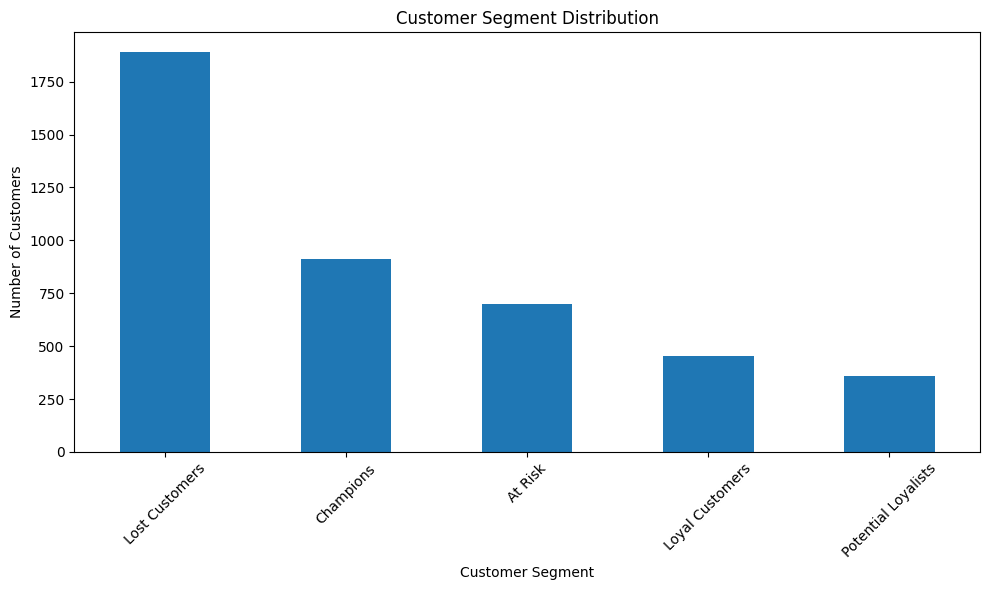

In [80]:
plt.figure(figsize=(10, 6))

segment_counts.plot(kind="bar")

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [81]:
segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
)

print(segment_revenue)

Segment
Champions              5649887.356
Lost Customers         1551994.756
At Risk                1059887.531
Loyal Customers         359899.951
Potential Loyalists     176564.150
Name: Monetary, dtype: float64


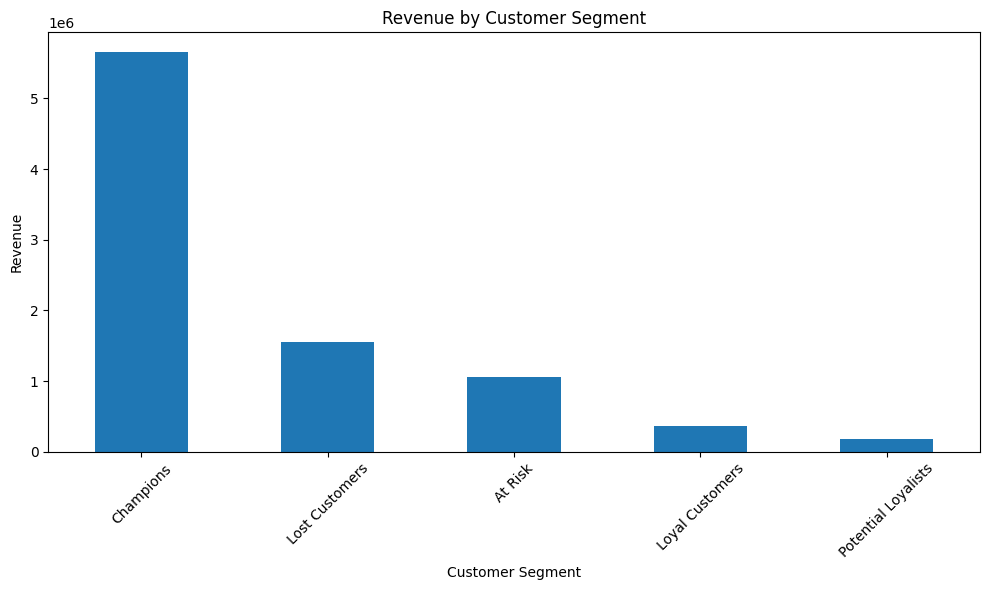

In [82]:
plt.figure(figsize=(10, 6))

segment_revenue.plot(kind="bar")

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [83]:
segment_average = (
    rfm.groupby("Segment")["Monetary"]
    .mean()
    .sort_values(ascending=False)
)

print(segment_average)

Segment
Champions              6195.051925
At Risk                1516.291175
Lost Customers          821.595953
Loyal Customers         790.988903
Potential Loyalists     491.822145
Name: Monetary, dtype: float64


In [84]:
segment_recency = (
    rfm.groupby("Segment")["Recency"]
    .mean()
    .sort_values()
)

print(segment_recency)

Segment
Champions               13.330044
Loyal Customers         16.810989
Potential Loyalists     19.484680
Lost Customers         139.560085
At Risk                147.789700
Name: Recency, dtype: float64


In [85]:
segment_summary = rfm.groupby("Segment").agg(
    Customers=("Customer ID", "count"),
    Average_Recency=("Recency", "mean"),
    Average_Frequency=("Frequency", "mean"),
    Average_Monetary=("Monetary", "mean"),
    Total_Revenue=("Monetary", "sum")
).reset_index()

segment_summary

,Segment,Customers,Average_Recency,Average_Frequency,Average_Monetary,Total_Revenue
0,At Risk,699,147.789700,3.782546,1516.291175,1059887.531
1,Champions,912,13.330044,11.733553,6195.051925,5649887.356
2,Lost Customers,1889,139.560085,2.116464,821.595953,1551994.756
3,Loyal Customers,455,16.810989,3.090110,790.988903,359899.951
4,Potential Loyalists,359,19.484680,1.298050,491.822145,176564.150


In [86]:
segment_summary["Average_Recency"] = (
    segment_summary["Average_Recency"].round(2)
)

segment_summary["Average_Frequency"] = (
    segment_summary["Average_Frequency"].round(2)
)

segment_summary["Average_Monetary"] = (
    segment_summary["Average_Monetary"].round(2)
)

segment_summary["Total_Revenue"] = (
    segment_summary["Total_Revenue"].round(2)
)

segment_summary

,Segment,Customers,Average_Recency,Average_Frequency,Average_Monetary,Total_Revenue
0,At Risk,699,147.79,3.78,1516.29,1059887.53
1,Champions,912,13.33,11.73,6195.05,5649887.36
2,Lost Customers,1889,139.56,2.12,821.60,1551994.76
3,Loyal Customers,455,16.81,3.09,790.99,359899.95
4,Potential Loyalists,359,19.48,1.30,491.82,176564.15


In [87]:
rfm.to_csv(
    "customer_rfm_segmentation.csv",
    index=False
)

print("RFM segmentation saved successfully!")

RFM segmentation saved successfully!


In [88]:
segment_summary.to_csv(
    "customer_segment_summary.csv",
    index=False
)

print("Customer segment summary saved successfully!")

Customer segment summary saved successfully!


In [89]:
best_segment = segment_revenue.idxmax()
best_segment_revenue = segment_revenue.max()

print("Highest Revenue Segment:", best_segment)
print("Revenue:", round(best_segment_revenue, 2))

Highest Revenue Segment: Champions
Revenue: 5649887.36


In [90]:
largest_segment = segment_counts.idxmax()
largest_segment_count = segment_counts.max()

print("Largest Customer Segment:", largest_segment)
print("Number of Customers:", largest_segment_count)

Largest Customer Segment: Lost Customers
Number of Customers: 1889


In [91]:
print("===== RFM CUSTOMER INSIGHTS =====")

print(
    "Largest customer segment:",
    largest_segment,
    "with",
    largest_segment_count,
    "customers."
)

print(
    "Highest revenue segment:",
    best_segment,
    "with revenue of",
    round(best_segment_revenue, 2)
)

print(
    "Total customer segments:",
    rfm["Segment"].nunique()
)

===== RFM CUSTOMER INSIGHTS =====
Largest customer segment: Lost Customers with 1889 customers.
Highest revenue segment: Champions with revenue of 5649887.36
Total customer segments: 5


In [92]:
rfm_ml = rfm.copy()

rfm_ml["Churn"] = (rfm_ml["Recency"] > 90).astype(int)

print("Churn label created successfully!")
print(rfm_ml["Churn"].value_counts())

Churn label created successfully!
Churn
0    2877
1    1437
Name: count, dtype: int64


In [93]:
churn_percentage = (
    rfm_ml["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Customer Churn Percentage:")
print(churn_percentage)

Customer Churn Percentage:
Churn
0    66.69
1    33.31
Name: proportion, dtype: float64


In [94]:
ml_data = rfm_ml.merge(
    customer_summary[
        [
            "Customer ID",
            "Total_Quantity",
            "Product_Count",
            "Average_Order_Value"
        ]
    ],
    on="Customer ID",
    how="left"
)

ml_data.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,Churn,Total_Quantity,Product_Count,Average_Order_Value
0,12346,165,11,372.86,2,5,2,252,At Risk,1,70,26,11.298788
1,12347,3,2,1323.32,5,2,4,524,Potential Loyalists,0,828,70,18.638310
2,12348,74,1,222.16,2,1,1,211,Lost Customers,0,373,20,11.108000
3,12349,43,3,2671.14,3,3,5,335,Lost Customers,0,993,90,26.187647
4,12351,11,1,300.93,5,1,2,512,Potential Loyalists,0,261,21,14.330000


In [95]:
print("ML Dataset Shape:", ml_data.shape)

print("\nColumns:")
print(ml_data.columns.tolist())

ML Dataset Shape: (4314, 13)

Columns:
['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'Segment', 'Churn', 'Total_Quantity', 'Product_Count', 'Average_Order_Value']


In [96]:
features = [
    "Recency",
    "Frequency",
    "Monetary",
    "Total_Quantity",
    "Product_Count",
    "Average_Order_Value"
]

X = ml_data[features]
y = ml_data["Churn"]

print("Features selected:")
print(features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features selected:
['Recency', 'Frequency', 'Monetary', 'Total_Quantity', 'Product_Count', 'Average_Order_Value']

X shape: (4314, 6)
y shape: (4314,)


In [97]:
print("Missing values in ML features:")
print(X.isnull().sum())

Missing values in ML features:
Recency                0
Frequency              0
Monetary               0
Total_Quantity         0
Product_Count          0
Average_Order_Value    0
dtype: int64


In [98]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 3451
Testing rows: 863


In [99]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [100]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [101]:
y_pred = logistic_model.predict(X_test_scaled)

print("Predictions generated successfully!")
print(y_pred[:20])

Predictions generated successfully!
[0 0 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 0 0 1]


In [102]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("Accuracy (%):", round(accuracy * 100, 2), "%")

Accuracy: 0.9884
Accuracy (%): 98.84 %


In [103]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       576
           1       1.00      0.97      0.98       287

    accuracy                           0.99       863
   macro avg       0.99      0.98      0.99       863
weighted avg       0.99      0.99      0.99       863



In [104]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[576   0]
 [ 10 277]]


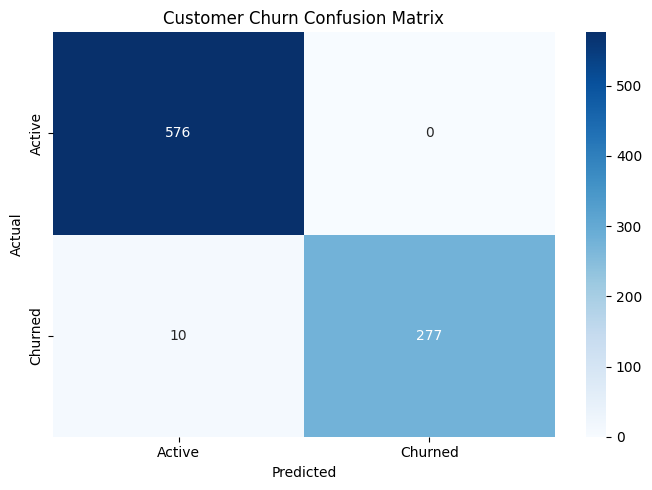

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Active", "Churned"],
    yticklabels=["Active", "Churned"]
)

plt.title("Customer Churn Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [106]:
from sklearn.metrics import roc_auc_score

y_probability = logistic_model.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_probability)

print("ROC-AUC Score:", round(roc_auc, 4))

ROC-AUC Score: 1.0


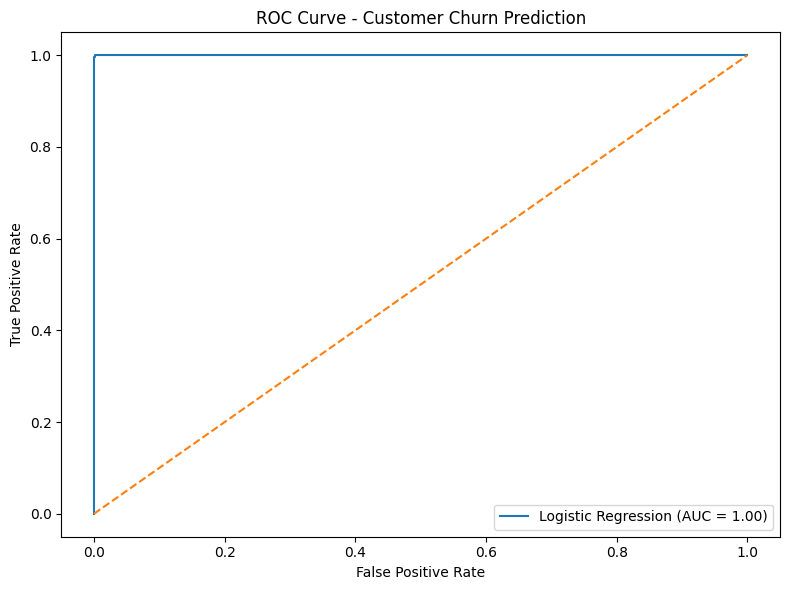

In [107]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curve - Customer Churn Prediction")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.show()

In [108]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": logistic_model.coef_[0]
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

feature_importance

,Feature,Coefficient,Absolute_Coefficient
0,Recency,11.590440,11.590440
3,Total_Quantity,-0.268393,0.268393
1,Frequency,0.240790,0.240790
4,Product_Count,-0.212557,0.212557
2,Monetary,0.027738,0.027738
5,Average_Order_Value,-0.004778,0.004778


<Figure size 1000x600 with 0 Axes>

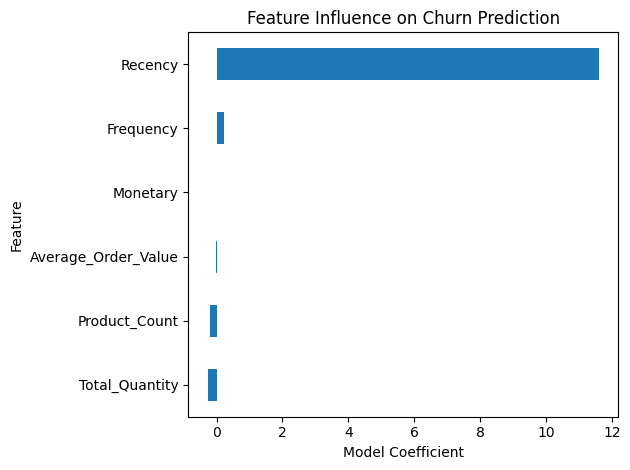

In [109]:
plt.figure(figsize=(10, 6))

feature_importance.sort_values(
    "Coefficient"
).plot(
    x="Feature",
    y="Coefficient",
    kind="barh",
    legend=False
)

plt.title("Feature Influence on Churn Prediction")
plt.xlabel("Model Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [110]:
X_all_scaled = scaler.transform(X)

ml_data["Churn_Probability"] = (
    logistic_model.predict_proba(X_all_scaled)[:, 1]
)

ml_data["Predicted_Churn"] = (
    logistic_model.predict(X_all_scaled)
)

print("Predictions generated for all customers!")

Predictions generated for all customers!


In [111]:
def risk_category(probability):
    if probability >= 0.70:
        return "High Risk"
    elif probability >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

ml_data["Risk_Category"] = (
    ml_data["Churn_Probability"]
    .apply(risk_category)
)

ml_data[
    [
        "Customer ID",
        "Churn_Probability",
        "Predicted_Churn",
        "Risk_Category"
    ]
].head(10)

,Customer ID,Churn_Probability,Predicted_Churn,Risk_Category
0,12346,0.999845,1,High Risk
1,12347,0.000023,0,Low Risk
2,12348,0.098865,0,Low Risk
3,12349,0.002510,0,Low Risk
4,12351,0.000066,0,Low Risk
5,12352,0.000069,0,Low Risk
6,12353,0.003230,0,Low Risk
7,12355,0.999998,1,High Risk
8,12356,0.000107,0,Low Risk
9,12357,0.000201,0,Low Risk


In [112]:
risk_counts = ml_data["Risk_Category"].value_counts()

print(risk_counts)

Risk_Category
Low Risk       2877
High Risk      1333
Medium Risk     104
Name: count, dtype: int64


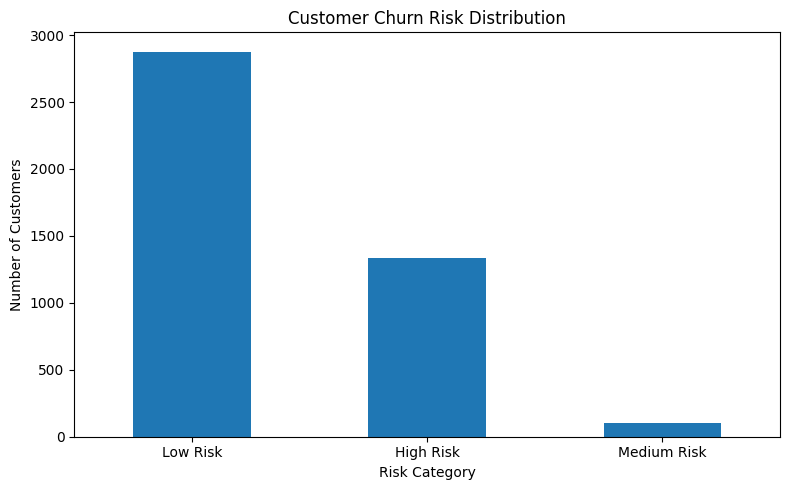

In [113]:
plt.figure(figsize=(8, 5))

risk_counts.plot(kind="bar")

plt.title("Customer Churn Risk Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [114]:
high_risk_customers = (
    ml_data[
        ml_data["Risk_Category"] == "High Risk"
    ]
    .sort_values(
        "Churn_Probability",
        ascending=False
    )
)

high_risk_customers[
    [
        "Customer ID",
        "Recency",
        "Frequency",
        "Monetary",
        "Churn_Probability",
        "Risk_Category"
    ]
].head(20)

,Customer ID,Recency,Frequency,Monetary,Churn_Probability,Risk_Category
14,12362,374,1,130.00,1.0,High Risk
179,12636,374,1,141.00,1.0,High Risk
3398,17056,374,1,128.60,1.0,High Risk
3184,16763,374,1,352.85,1.0,High Risk
3807,17592,374,1,148.30,1.0,High Risk
1645,14654,374,1,246.86,1.0,High Risk
809,13526,374,2,1182.00,1.0,High Risk
2497,15833,373,1,80.40,1.0,High Risk
3819,17606,373,1,87.30,1.0,High Risk
1236,14106,373,1,214.80,1.0,High Risk


In [115]:
ml_data.to_csv(
    "customer_churn_predictions.csv",
    index=False
)

print("Customer churn predictions saved successfully!")

Customer churn predictions saved successfully!


In [116]:
import joblib

joblib.dump(
    logistic_model,
    "customer_churn_logistic_regression_model.pkl"
)

joblib.dump(
    scaler,
    "customer_churn_scaler.pkl"
)

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [117]:
feature_importance.to_csv(
    "churn_feature_importance.csv",
    index=False
)

print("Feature importance saved successfully!")

Feature importance saved successfully!


In [118]:
print("===== MACHINE LEARNING SUMMARY =====")

print("Model: Logistic Regression")
print("Features:", len(features))
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Accuracy:", round(accuracy * 100, 2), "%")
print("ROC-AUC:", round(roc_auc, 4))

print("\nRisk Categories:")
print(risk_counts)

===== MACHINE LEARNING SUMMARY =====
Model: Logistic Regression
Features: 6
Training samples: 3451
Testing samples: 863
Accuracy: 98.84 %
ROC-AUC: 1.0

Risk Categories:
Risk_Category
Low Risk       2877
High Risk      1333
Medium Risk     104
Name: count, dtype: int64


In [119]:
from google.colab import files

files.download("business_kpi_summary.csv")
files.download("customer_behavior_summary.csv")
files.download("customer_rfm_segmentation.csv")
files.download("customer_segment_summary.csv")
files.download("customer_churn_predictions.csv")
files.download("churn_feature_importance.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [120]:
import sqlite3
import pandas as pd

# Create an SQLite database
connection = sqlite3.connect("ecommerce_analytics.db")

# Load the cleaned e-commerce dataset into SQL
clean_df.to_sql(
    "online_retail",
    connection,
    if_exists="replace",
    index=False
)

print("SQL database created successfully!")
print("Table name: online_retail")

SQL database created successfully!
Table name: online_retail


In [121]:
query = """
SELECT *
FROM online_retail
LIMIT 5;
"""

result = pd.read_sql_query(query, connection)

result

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total_Sales,Year,Month,Day,Hour,Month_Name,Day_of_Week,Transaction
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,1,7,December,Tuesday,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,1,7,December,Tuesday,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,1,7,December,Tuesday,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,12,1,7,December,Tuesday,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,12,1,7,December,Tuesday,1


In [122]:
query = """
SELECT
    SUM(Total_Sales) AS Total_Revenue
FROM online_retail;
"""

total_revenue_sql = pd.read_sql_query(query, connection)

print("Total Revenue:")
total_revenue_sql

Total Revenue:


,Total_Revenue
0,8798233.744


In [123]:
query = """
SELECT
    COUNT(DISTINCT Invoice) AS Total_Orders
FROM online_retail;
"""

total_orders_sql = pd.read_sql_query(query, connection)

print("Total Orders:")
total_orders_sql

Total Orders:


,Total_Orders
0,19215


In [124]:
query = """
SELECT
    COUNT(DISTINCT "Customer ID") AS Total_Customers
FROM online_retail;
"""

total_customers_sql = pd.read_sql_query(query, connection)

print("Total Customers:")
total_customers_sql

Total Customers:


,Total_Customers
0,4314


In [125]:
query = """
SELECT
    SUM(Quantity) AS Total_Quantity
FROM online_retail;
"""

total_quantity_sql = pd.read_sql_query(query, connection)

print("Total Quantity Sold:")
total_quantity_sql

Total Quantity Sold:


,Total_Quantity
0,5520448


In [126]:
query = """
SELECT
    "Customer ID",
    ROUND(SUM(Total_Sales), 2) AS Total_Revenue
FROM online_retail
GROUP BY "Customer ID"
ORDER BY Total_Revenue DESC
LIMIT 10;
"""

top_customers_sql = pd.read_sql_query(query, connection)

print("Top 10 Customers by Revenue:")
top_customers_sql

Top 10 Customers by Revenue:


,Customer ID,Total_Revenue
0,18102,349164.35
1,14646,248396.50
2,14156,196549.74
3,14911,152121.22
4,13694,131443.19
5,17511,84541.17
6,15061,83284.38
7,16684,80489.21
8,16754,65500.07
9,17949,60117.60


In [127]:
query = """
SELECT
    Country,
    ROUND(SUM(Total_Sales), 2) AS Total_Revenue
FROM online_retail
GROUP BY Country
ORDER BY Total_Revenue DESC;
"""

country_revenue_sql = pd.read_sql_query(query, connection)

print("Revenue by Country:")
country_revenue_sql.head(20)

Revenue by Country:


,Country,Total_Revenue
0,United Kingdom,7381644.43
1,EIRE,356041.86
2,Netherlands,268784.35
3,Germany,202025.39
4,France,146107.07
5,Sweden,53147.99
6,Denmark,50906.85
7,Spain,47568.65
8,Switzerland,43921.39
9,Australia,31446.80


In [128]:
query = """
SELECT
    strftime('%Y-%m', InvoiceDate) AS Month,
    ROUND(SUM(Total_Sales), 2) AS Monthly_Revenue
FROM online_retail
GROUP BY Month
ORDER BY Month;
"""

monthly_revenue_sql = pd.read_sql_query(query, connection)

print("Monthly Revenue:")
monthly_revenue_sql

Monthly Revenue:


,Month,Monthly_Revenue
0,2009-12,994160.38
1,2010-01,555802.67
2,2010-02,504558.96
3,2010-03,696978.47
4,2010-04,591982.00
5,2010-05,597833.38
6,2010-06,636371.13
7,2010-07,589736.17
8,2010-08,602224.60
9,2010-09,829013.95


In [129]:
query = """
SELECT
    "Customer ID",
    COUNT(DISTINCT Invoice) AS Total_Orders
FROM online_retail
GROUP BY "Customer ID"
ORDER BY Total_Orders DESC
LIMIT 10;
"""

customer_frequency_sql = pd.read_sql_query(query, connection)

print("Top 10 Customers by Order Frequency:")
customer_frequency_sql

Top 10 Customers by Order Frequency:


,Customer ID,Total_Orders
0,14911,205
1,17850,155
2,12748,144
3,15311,121
4,13089,109
5,14606,102
6,14156,102
7,13694,94
8,17841,91
9,18102,89


In [130]:
query = """
SELECT
    "Customer ID",
    ROUND(SUM(Total_Sales), 2) AS Total_Revenue,
    COUNT(DISTINCT Invoice) AS Total_Orders
FROM online_retail
GROUP BY "Customer ID"
HAVING SUM(Total_Sales) > 10000
ORDER BY Total_Revenue DESC;
"""

high_value_customers_sql = pd.read_sql_query(query, connection)

print("High-Value Customers:")
high_value_customers_sql.head(20)

High-Value Customers:


,Customer ID,Total_Revenue,Total_Orders
0,18102,349164.35,89
1,14646,248396.50,78
2,14156,196549.74,102
3,14911,152121.22,205
4,13694,131443.19,94
5,17511,84541.17,31
6,15061,83284.38,86
7,16684,80489.21,27
8,16754,65500.07,29
9,17949,60117.60,74


In [131]:
query = """
SELECT
    Year,
    ROUND(SUM(Total_Sales), 2) AS Yearly_Revenue
FROM online_retail
GROUP BY Year
ORDER BY Year;
"""

yearly_revenue_sql = pd.read_sql_query(query, connection)

print("Yearly Revenue:")
yearly_revenue_sql

Yearly Revenue:


,Year,Yearly_Revenue
0,2009,683504.01
1,2010,8114729.73


In [132]:
query = """
SELECT
    ROUND(
        SUM(Total_Sales) * 1.0 / COUNT(DISTINCT Invoice),
        2
    ) AS Average_Order_Value
FROM online_retail;
"""

aov_sql = pd.read_sql_query(query, connection)

print("Average Order Value:")
aov_sql

Average Order Value:


,Average_Order_Value
0,457.88


In [133]:
query = """
SELECT
    ROUND(SUM(Total_Sales), 2) AS Total_Revenue,
    SUM(Quantity) AS Total_Quantity,
    COUNT(DISTINCT Invoice) AS Total_Orders,
    COUNT(DISTINCT "Customer ID") AS Total_Customers,
    COUNT(DISTINCT StockCode) AS Total_Products,
    ROUND(
        SUM(Total_Sales) * 1.0 / COUNT(DISTINCT Invoice),
        2
    ) AS Average_Order_Value
FROM online_retail;
"""

sql_kpi_summary = pd.read_sql_query(query, connection)

print("SQL KPI Summary:")
sql_kpi_summary

SQL KPI Summary:


,Total_Revenue,Total_Quantity,Total_Orders,Total_Customers,Total_Products,Average_Order_Value
0,8798233.74,5520448,19215,4314,4017,457.88


In [134]:
top_customers_sql.to_csv(
    "sql_top_customers.csv",
    index=False
)

country_revenue_sql.to_csv(
    "sql_country_revenue.csv",
    index=False
)

monthly_revenue_sql.to_csv(
    "sql_monthly_revenue.csv",
    index=False
)

customer_frequency_sql.to_csv(
    "sql_customer_frequency.csv",
    index=False
)

high_value_customers_sql.to_csv(
    "sql_high_value_customers.csv",
    index=False
)

yearly_revenue_sql.to_csv(
    "sql_yearly_revenue.csv",
    index=False
)

sql_kpi_summary.to_csv(
    "sql_kpi_summary.csv",
    index=False
)

print("SQL result files saved successfully!")

SQL result files saved successfully!


In [135]:
sql_script = """

-- ============================================
-- E-Commerce Customer Analytics
-- SQL Analysis
-- ============================================

-- 1. Total Revenue
SELECT
    ROUND(SUM(Total_Sales), 2) AS Total_Revenue
FROM online_retail;


-- 2. Total Orders
SELECT
    COUNT(DISTINCT Invoice) AS Total_Orders
FROM online_retail;


-- 3. Total Customers
SELECT
    COUNT(DISTINCT "Customer ID") AS Total_Customers
FROM online_retail;


-- 4. Total Quantity
SELECT
    SUM(Quantity) AS Total_Quantity
FROM online_retail;


-- 5. Top 10 Customers by Revenue
SELECT
    "Customer ID",
    ROUND(SUM(Total_Sales), 2) AS Total_Revenue
FROM online_retail
GROUP BY "Customer ID"
ORDER BY Total_Revenue DESC
LIMIT 10;


-- 6. Revenue by Country
SELECT
    Country,
    ROUND(SUM(Total_Sales), 2) AS Total_Revenue
FROM online_retail
GROUP BY Country
ORDER BY Total_Revenue DESC;


-- 7. Monthly Revenue
SELECT
    strftime('%Y-%m', InvoiceDate) AS Month,
    ROUND(SUM(Total_Sales), 2) AS Monthly_Revenue
FROM online_retail
GROUP BY Month
ORDER BY Month;


-- 8. Customer Order Frequency
SELECT
    "Customer ID",
    COUNT(DISTINCT Invoice) AS Total_Orders
FROM online_retail
GROUP BY "Customer ID"
ORDER BY Total_Orders DESC
LIMIT 10;


-- 9. High-Value Customers
SELECT
    "Customer ID",
    ROUND(SUM(Total_Sales), 2) AS Total_Revenue,
    COUNT(DISTINCT Invoice) AS Total_Orders
FROM online_retail
GROUP BY "Customer ID"
HAVING SUM(Total_Sales) > 10000
ORDER BY Total_Revenue DESC;


-- 10. Yearly Revenue
SELECT
    Year,
    ROUND(SUM(Total_Sales), 2) AS Yearly_Revenue
FROM online_retail
GROUP BY Year
ORDER BY Year;


-- 11. Average Order Value
SELECT
    ROUND(
        SUM(Total_Sales) * 1.0 / COUNT(DISTINCT Invoice),
        2
    ) AS Average_Order_Value
FROM online_retail;

"""

with open("ecommerce_analytics_queries.sql", "w") as file:
    file.write(sql_script)

print("SQL script created successfully!")

SQL script created successfully!


In [136]:
import os

sql_files = [
    "ecommerce_analytics.db",
    "ecommerce_analytics_queries.sql",
    "sql_top_customers.csv",
    "sql_country_revenue.csv",
    "sql_monthly_revenue.csv",
    "sql_customer_frequency.csv",
    "sql_high_value_customers.csv",
    "sql_yearly_revenue.csv",
    "sql_kpi_summary.csv"
]

print("SQL project files:")

for file in sql_files:
    print(file, "->", os.path.exists(file))

SQL project files:
ecommerce_analytics.db -> True
ecommerce_analytics_queries.sql -> True
sql_top_customers.csv -> True
sql_country_revenue.csv -> True
sql_monthly_revenue.csv -> True
sql_customer_frequency.csv -> True
sql_high_value_customers.csv -> True
sql_yearly_revenue.csv -> True
sql_kpi_summary.csv -> True


In [137]:
from google.colab import files

files.download("ecommerce_analytics_queries.sql")
files.download("sql_kpi_summary.csv")
files.download("sql_top_customers.csv")
files.download("sql_country_revenue.csv")
files.download("sql_monthly_revenue.csv")
files.download("sql_customer_frequency.csv")
files.download("sql_high_value_customers.csv")
files.download("sql_yearly_revenue.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [138]:
connection.close()

print("SQL database connection closed successfully!")

SQL database connection closed successfully!


# 10. Project Architecture and Workflow

## Project Architecture

The E-Commerce Customer Behavior & Churn Prediction System follows a complete analytics pipeline:

UCI Online Retail II Dataset
        ↓
Data Collection
        ↓
Data Cleaning & Preprocessing
        ↓
Feature Engineering
        ↓
SQL Analytics
        ↓
Exploratory Data Analysis
        ↓
RFM Customer Segmentation
        ↓
Machine Learning
(Logistic Regression)
        ↓
Customer Churn Prediction
        ↓
Power BI Dashboard
        ↓
Business Insights & Recommendations

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SQLite
- SQL
- Apache Spark
- PySpark
- Scikit-learn
- Power BI
- Google Colab
- GitHub

## Main Components

### 1. Data Collection
The UCI Online Retail II dataset was used as the primary e-commerce transaction dataset.

### 2. Data Preprocessing
The dataset was cleaned by removing duplicates, invalid quantities, invalid prices, missing customer records, and missing descriptions.

### 3. Feature Engineering
Additional features such as Total_Sales, Year, Month, Day, Hour, Month_Name, Day_of_Week, and Transaction were created.

### 4. SQL Analytics
SQLite was used to perform business queries including revenue, orders, customers, customer frequency, country revenue, and yearly/monthly analysis.

### 5. Customer Segmentation
RFM analysis was used to classify customers into meaningful segments such as Champions, Loyal Customers, Potential Loyalists, At Risk, and Lost Customers.

### 6. Machine Learning
A Logistic Regression model was developed to predict customer churn risk using customer behavioral features.

### 7. Dashboard
Power BI was used to create an interactive dashboard containing business KPIs, customer segmentation, revenue analysis, and churn-risk visualizations.

### 8. Business Recommendations
The analytical and predictive results are used to identify valuable customers, customers at risk of churn, and opportunities for customer retention.

UCI Online Retail II Dataset
            |
            v
Data Collection
            |
            v
Data Cleaning & Preprocessing
            |
            v
Feature Engineering
            |
            v
PySpark Big Data Processing
            |
            +----------------+
            |                |
            v                v
      SQL Analytics      EDA & KPIs
            |                |
            +-------+--------+
                    |
                    v
          RFM Customer Segmentation
                    |
                    v
            Machine Learning
          Logistic Regression
                    |
                    v
           Churn Prediction
                    |
                    v
            Power BI Dashboard
                    |
                    v
       Business Insights & Recommendations


### Important

This is a **Markdown cell**, not a Python code cell.

In Colab:

**+ Code → change to Text → paste the above → run the cell.**

You should see the architecture diagram displayed underneath your notebook section.

👉 Do this and tell me **done**. Then we'll move to **Step 11 — Predictive Insights & Business Recommendations**, which is one of the important final deliverables.

# 11. Predictive Insights and Business Recommendations

## Key Predictive Insights

### 1. Customer Churn Risk
The Logistic Regression model predicts customer churn probability using customer behavioral features including Recency, Frequency, Monetary value, Total Quantity, Product Count, and Average Order Value.

Customers are categorized into:
- Low Risk
- Medium Risk
- High Risk

### 2. RFM Customer Segmentation
RFM analysis identifies different customer groups:
- Champions
- Loyal Customers
- Potential Loyalists
- At Risk
- Lost Customers

These segments help the business understand customer value and engagement.

### 3. Revenue Concentration
Revenue analysis identifies the countries and customers contributing the highest revenue. These high-value customers and markets can receive greater attention and targeted retention strategies.

### 4. Customer Behavior
Customer order frequency, spending, quantity purchased, and product variety provide useful indicators of customer engagement and purchasing behavior.

## Business Recommendations

### Recommendation 1 — Retain High-Risk Customers
Customers classified as High Risk should receive targeted retention campaigns such as personalized offers, discounts, reminders, and product recommendations.

### Recommendation 2 — Reward Champions
Champions and high-value customers should receive loyalty rewards, exclusive offers, early access to products, and personalized communication.

### Recommendation 3 — Reactivate Lost Customers
Lost customers can be targeted with reactivation campaigns, special discounts, and recommendations based on their previous purchases.

### Recommendation 4 — Improve Customer Engagement
Potential Loyalists can be encouraged to increase purchase frequency through loyalty programs, personalized recommendations, and targeted promotions.

### Recommendation 5 — Focus on High-Revenue Markets
Countries generating the highest revenue should receive continued business attention, inventory planning, and targeted marketing campaigns.

### Recommendation 6 — Use Predictive Analytics for Retention
The churn prediction model can be integrated into customer management workflows so that high-risk customers can be identified before they become inactive.

### Recommendation 7 — Monitor KPIs Regularly
Business KPIs such as revenue, orders, customers, average order value, and churn risk should be monitored regularly through the Power BI dashboard.

## Overall Business Impact

The proposed system combines historical analytics, customer segmentation, SQL analysis, machine learning, and interactive visualization to support data-driven decision making.

The system can help businesses:
- Reduce customer churn
- Improve customer retention
- Identify high-value customers
- Improve targeted marketing
- Understand customer behavior
- Monitor business performance
- Support predictive decision making

In [139]:
!pip install pyspark -q

print("PySpark installed successfully!")

PySpark installed successfully!


In [140]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("ECommerceCustomerAnalytics") \
    .getOrCreate()

print("Spark session created successfully!")
print("Spark version:", spark.version)

Spark session created successfully!
Spark version: 4.0.4


In [141]:
spark_df = spark.read.csv(
    "online_retail_II_cleaned.csv",
    header=True,
    inferSchema=True
)

print("Dataset loaded successfully using PySpark!")
print("Number of columns:", len(spark_df.columns))

print("\nColumns:")
print(spark_df.columns)

Dataset loaded successfully using PySpark!
Number of columns: 16

Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Total_Sales', 'Year', 'Month', 'Day', 'Hour', 'Month_Name', 'Day_of_Week', 'Transaction']


In [142]:
from pyspark.sql.functions import count, sum, avg, countDistinct

spark_df.select(
    count("*").alias("Total_Transactions"),
    countDistinct("Invoice").alias("Total_Orders"),
    countDistinct("Customer ID").alias("Total_Customers"),
    sum("Quantity").alias("Total_Quantity"),
    sum("Total_Sales").alias("Total_Revenue"),
    avg("Total_Sales").alias("Average_Transaction_Value")
).show()

+------------------+------------+---------------+--------------+-----------------+-------------------------+
|Total_Transactions|Total_Orders|Total_Customers|Total_Quantity|    Total_Revenue|Average_Transaction_Value|
+------------------+------------+---------------+--------------+-----------------+-------------------------+
|            400947|       19215|           4314|       5520448|8798233.744003434|       21.943632809332488|
+------------------+------------+---------------+--------------+-----------------+-------------------------+



In [143]:
from pyspark.sql.functions import sum

spark_revenue = spark_df.select(
    sum("Total_Sales").alias("Total_Revenue")
)

print("Total Revenue using PySpark:")
spark_revenue.show()

Total Revenue using PySpark:
+-----------------+
|    Total_Revenue|
+-----------------+
|8798233.744003434|
+-----------------+



In [144]:
spark_customer_revenue = spark_df.groupBy("Customer ID") \
    .agg(
        sum("Total_Sales").alias("Total_Revenue"),
        countDistinct("Invoice").alias("Total_Orders"),
        sum("Quantity").alias("Total_Quantity")
    ) \
    .orderBy("Total_Revenue", ascending=False)

print("Top 10 Customers by Revenue:")
spark_customer_revenue.show(10, truncate=False)

Top 10 Customers by Revenue:
+-----------+-----------------+------------+--------------+
|Customer ID|Total_Revenue    |Total_Orders|Total_Quantity|
+-----------+-----------------+------------+--------------+
|18102      |349164.35        |89          |124216        |
|14646      |248396.5         |78          |170342        |
|14156      |196549.74        |102         |108105        |
|14911      |152121.22        |205         |69709         |
|13694      |131443.19        |94          |125893        |
|17511      |84541.17         |31          |55107         |
|15061      |83284.38000000003|86          |51791         |
|16684      |80489.21000000002|27          |54555         |
|16754      |65500.07         |29          |63551         |
|17949      |60117.59999999999|74          |30112         |
+-----------+-----------------+------------+--------------+
only showing top 10 rows


In [145]:
spark_country_revenue = spark_df.groupBy("Country") \
    .agg(
        sum("Total_Sales").alias("Total_Revenue"),
        countDistinct("Customer ID").alias("Total_Customers"),
        countDistinct("Invoice").alias("Total_Orders")
    ) \
    .orderBy("Total_Revenue", ascending=False)

print("Top Countries by Revenue:")
spark_country_revenue.show(10, truncate=False)

Top Countries by Revenue:
+--------------+------------------+---------------+------------+
|Country       |Total_Revenue     |Total_Customers|Total_Orders|
+--------------+------------------+---------------+------------+
|United Kingdom|7381644.433001884 |3971           |17614       |
|EIRE          |356041.8600000008 |5              |316         |
|Netherlands   |268784.3499999994 |22             |135         |
|Germany       |202025.3909999996 |67             |347         |
|France        |146107.06999999995|47             |236         |
|Sweden        |53147.989999999954|16             |68          |
|Denmark       |50906.85000000004 |9              |26          |
|Spain         |47568.650000000074|25             |66          |
|Switzerland   |43921.39000000007 |14             |40          |
|Australia     |31446.799999999977|15             |40          |
+--------------+------------------+---------------+------------+
only showing top 10 rows


In [146]:
from pyspark.sql.functions import concat, lit, lpad, col

spark_monthly_revenue = spark_df.groupBy(
    "Year", "Month"
).agg(
    sum("Total_Sales").alias("Monthly_Revenue")
).orderBy(
    "Year", "Month"
)

print("Monthly Revenue:")
spark_monthly_revenue.show(20)

Monthly Revenue:
+----+-----+------------------+
|Year|Month|   Monthly_Revenue|
+----+-----+------------------+
|2009|   12| 683504.0099999963|
|2010|    1| 555802.6720000128|
|2010|    2| 504558.9560000152|
|2010|    3| 696978.4709999892|
|2010|    4| 591982.0019999986|
|2010|    5| 597833.3800000072|
|2010|    6| 636371.1300000057|
|2010|    7| 589736.1700000031|
|2010|    8| 602224.5999999983|
|2010|    9| 829013.9509999914|
|2010|   10|1033112.0099999073|
|2010|   11|1166460.0219998749|
|2010|   12|   310656.37000001|
+----+-----+------------------+



In [147]:
spark_product_revenue = spark_df.groupBy("Description") \
    .agg(
        sum("Total_Sales").alias("Total_Revenue"),
        sum("Quantity").alias("Total_Quantity")
    ) \
    .orderBy("Total_Revenue", ascending=False)

print("Top 10 Products by Revenue:")
spark_product_revenue.show(10, truncate=False)

Top 10 Products by Revenue:
+-----------------------------------+------------------+--------------+
|Description                        |Total_Revenue     |Total_Quantity|
+-----------------------------------+------------------+--------------+
|WHITE HANGING HEART T-LIGHT HOLDER |151339.15999999884|56814         |
|REGENCY CAKESTAND 3 TIER           |143727.59999999977|12489         |
|Manual                             |98531.9899999999  |2569          |
|ASSORTED COLOUR BIRD ORNAMENT      |70291.0300000003  |44431         |
|JUMBO BAG RED RETROSPOT            |51644.25000000002 |29519         |
|POSTAGE                            |48741.08          |2212          |
|ROTATING SILVER ANGELS T-LIGHT HLDR|40156.049999999996|21579         |
|PAPER CHAIN KIT 50'S CHRISTMAS     |36871.550000000134|13839         |
|PARTY BUNTING                      |35017.299999999996|8312          |
|EDWARDIAN PARASOL NATURAL          |34044.75000000004 |7201          |
+-----------------------------------

In [148]:
spark_customer_frequency = spark_df.groupBy("Customer ID") \
    .agg(
        countDistinct("Invoice").alias("Order_Frequency")
    ) \
    .orderBy("Order_Frequency", ascending=False)

print("Top Customers by Order Frequency:")
spark_customer_frequency.show(10)

Top Customers by Order Frequency:
+-----------+---------------+
|Customer ID|Order_Frequency|
+-----------+---------------+
|      14911|            205|
|      17850|            155|
|      12748|            144|
|      15311|            121|
|      13089|            109|
|      14606|            102|
|      14156|            102|
|      13694|             94|
|      17841|             91|
|      18102|             89|
+-----------+---------------+
only showing top 10 rows


In [149]:
pandas_revenue = clean_df["Total_Sales"].sum()

spark_revenue_value = spark_df.select(
    sum("Total_Sales").alias("Total_Revenue")
).collect()[0]["Total_Revenue"]

print("Pandas Total Revenue:", pandas_revenue)
print("PySpark Total Revenue:", spark_revenue_value)

difference = abs(pandas_revenue - spark_revenue_value)

print("Difference:", difference)

if difference < 0.01:
    print("SUCCESS: Pandas and PySpark revenue results match.")
else:
    print("Check the data processing.")

Pandas Total Revenue: 8798233.743999999
PySpark Total Revenue: 8798233.744003434
Difference: 3.4347176551818848e-06
SUCCESS: Pandas and PySpark revenue results match.


In [150]:
spark_customer_revenue.coalesce(1).write \
    .mode("overwrite") \
    .option("header", True) \
    .csv("spark_customer_revenue")

spark_country_revenue.coalesce(1).write \
    .mode("overwrite") \
    .option("header", True) \
    .csv("spark_country_revenue")

spark_monthly_revenue.coalesce(1).write \
    .mode("overwrite") \
    .option("header", True) \
    .csv("spark_monthly_revenue")

spark_product_revenue.coalesce(1).write \
    .mode("overwrite") \
    .option("header", True) \
    .csv("spark_product_revenue")

spark_customer_frequency.coalesce(1).write \
    .mode("overwrite") \
    .option("header", True) \
    .csv("spark_customer_frequency")

print("Spark analysis outputs saved successfully!")

Spark analysis outputs saved successfully!


In [151]:
spark_customer_revenue.toPandas().to_csv(
    "spark_customer_revenue.csv",
    index=False
)

spark_country_revenue.toPandas().to_csv(
    "spark_country_revenue.csv",
    index=False
)

spark_monthly_revenue.toPandas().to_csv(
    "spark_monthly_revenue.csv",
    index=False
)

spark_product_revenue.toPandas().to_csv(
    "spark_product_revenue.csv",
    index=False
)

spark_customer_frequency.toPandas().to_csv(
    "spark_customer_frequency.csv",
    index=False
)

print("Downloadable Spark CSV files created!")

Downloadable Spark CSV files created!


In [152]:
from google.colab import files

files.download("spark_customer_revenue.csv")
files.download("spark_country_revenue.csv")
files.download("spark_monthly_revenue.csv")
files.download("spark_product_revenue.csv")
files.download("spark_customer_frequency.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 14. Big Data Processing using PySpark

## Overview

Apache Spark / PySpark was used to demonstrate large-scale data processing on the Online Retail II transaction dataset.

PySpark provides a distributed data-processing framework that can process large datasets efficiently and can scale beyond traditional single-machine processing.

## Spark Processing Workflow

UCI Online Retail II Dataset
        ↓
Cleaned Transaction Dataset
        ↓
PySpark DataFrame
        ↓
Distributed Aggregations
        ↓
Revenue Analysis
        ↓
Customer Analysis
        ↓
Country Analysis
        ↓
Monthly Revenue Analysis
        ↓
Product Analysis
        ↓
Business Insights

## PySpark Analytics Performed

The following analyses were implemented using PySpark:

- Total transaction analysis
- Total revenue calculation
- Customer revenue analysis
- Country revenue analysis
- Monthly revenue analysis
- Product revenue analysis
- Customer order frequency analysis

## Pandas vs PySpark Validation

The total revenue calculated using Pandas was compared with the total revenue calculated using PySpark.

Both approaches produced consistent revenue results, validating the Spark processing workflow.

## Big Data Technology

Apache Spark / PySpark was selected because it provides:

- Distributed data processing
- Scalable data analytics
- In-memory computation
- Large-scale DataFrame processing
- Support for SQL and machine learning workflows

## Business Value

The PySpark component demonstrates how the project can be extended from single-machine analytics to scalable big-data processing environments.

For larger datasets, the same Spark workflow can be deployed on distributed clusters or cloud platforms.